# Blasting Sound Signal Analysis
## IAESTE Internship 2026 — VŠB-TU Ostrava

This notebook implements full signal processing analysis for abrasive blasting sound recordings
collected at the VŠB-TU Ostrava experimental facility.

### Objectives
1. Load acoustic signals (WAV) from the experimental database
2. Automatically detect the onset of the blasting process
3. Skip the 6–8 s startup transient after onset; extract the useful signal
4. Apply floating (overlapping) analysis windows of 5–10 s
5. Filter each window with five bandpass filter types at orders 3, 5, and 7
6. Compute six signal parameters per filtered band
7. Compare filter types by reliability and computational complexity

### Frequency Bands (Hz) — as specified by mentor
| # | Low | High |
|---|-----|------|
| 1 | 176 | 225 |
| 2 | 225 | 283 |
| 3 | 283 | 353 |
| 4 | 353 | 440 |
| 5 | 440 | 565 |
| 6 | 565 | 707 |
| 7 | 707 | 880 |
| 8 | 880 | 1130 |
| 9 | 1130 | 1414 |
|10 | 1414 | 1760 |
|11 | 1760 | 2220 |
|12 | 10   | 1000 |
|13 | 10   | 2000 |
|14 | 500  | 1500 |
|15 | 1000 | 2000 |

### Signal Parameters Computed per Band
| Parameter | Symbol | Description |
|-----------|--------|-------------|
| RMS | x_rms | Root Mean Square — proportional to signal energy/power |
| Peak | x_pk | Maximum absolute amplitude in the window |
| Crest Factor | CF | x_pk / x_rms — measures impulsiveness of the signal |
| Zero Crossing Rate | ZCR | Sign changes per second — related to dominant frequency |
| Band Power | P | Integral of PSD over the frequency band (Welch method) |
| Spectral Centroid | f_c | Frequency weighted mean of the power spectrum |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import (
    butter, cheby1, cheby2, ellip, bessel,
    sosfilt, sosfiltfilt, sosfreqz,
    welch, spectrogram as sp_spectrogram,
)
from scipy.io import wavfile
import pandas as pd
import time
import os
from pathlib import Path
from itertools import product

# Consistent figure appearance
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['axes.titlesize'] = 11

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# ── PROJECT PATHS ──────────────────────────────────────────────────────────────
BASE_DIR = Path(r"D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main")
DATA_DIR = BASE_DIR / "data"

# Default WAV file for analysis
# Naming: MATERIAL_NOZZLE_PRESSURE_MIXRATIO_SENSOR.wav
# G80 = Steel Grit G80, 8 mm nozzle, 3 bar, 0 % mix ratio, Microphone 46BE
EXAMPLE_WAV = DATA_DIR / "v24" / "WAV" / "G80_8_3_0_Mic46BE.wav"

# ── BLAST DETECTION PARAMETERS ─────────────────────────────────────────────────
ENERGY_WINDOW_S  = 0.05   # Short-time energy frame length (s)
NOISE_DURATION_S = 0.5    # Initial quiet section used to estimate noise floor (s)
ONSET_THRESHOLD  = 10.0   # Onset when frame energy > ONSET_THRESHOLD * noise_floor
ONSET_OFFSET_S   = 7.0    # Seconds to skip after onset (midpoint of 6–8 s range)

# ── ANALYSIS WINDOW PARAMETERS ─────────────────────────────────────────────────
WINDOW_DURATION_S = 5.0   # Floating window length (s); can range 5–10 s
WINDOW_STEP_S     = 1.0   # Step between consecutive windows (s)

# ── FREQUENCY BANDS (Hz) ───────────────────────────────────────────────────────
LOWER_LIMITS = [176, 225, 283, 353, 440, 565, 707,  880, 1130, 1414, 1760,   10,   10,  500, 1000]
UPPER_LIMITS = [225, 283, 353, 440, 565, 707, 880, 1130, 1414, 1760, 2220, 1000, 2000, 1500, 2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo, hi in zip(LOWER_LIMITS, UPPER_LIMITS)]

# ── FILTER CONFIGURATION ───────────────────────────────────────────────────────
FILTER_TYPES  = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptical', 'Bessel']
FILTER_ORDERS = [3, 5, 7]

# Extra design parameters (from scipy defaults, made explicit for documentation)
CHEBY1_RIPPLE_DB = 0.5    # Maximum passband ripple for Chebyshev I (dB)
CHEBY2_ATTEN_DB  = 40.0   # Minimum stopband attenuation for Chebyshev II (dB)
ELLIP_RIPPLE_DB  = 0.5    # Maximum passband ripple for Elliptical (dB)
ELLIP_ATTEN_DB   = 40.0   # Minimum stopband attenuation for Elliptical (dB)

print(f"Frequency bands          : {N_BANDS}")
print(f"Filter types             : {FILTER_TYPES}")
print(f"Filter orders            : {FILTER_ORDERS}")
print(f"Total filter combinations: {N_BANDS * len(FILTER_TYPES) * len(FILTER_ORDERS)}")


Frequency bands          : 15
Filter types             : ['Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptical', 'Bessel']
Filter orders            : [3, 5, 7]
Total filter combinations: 225


## 1. Load WAV File

### File Naming Convention
```
MATERIAL_NOZZLE_PRESSURE_MIXRATIO_SENSOR[_REPETITION].wav
```
| Field | Example | Meaning |
|-------|---------|---------|
| MATERIAL | G80 | Steel Grit G80 abrasive |
| NOZZLE | 8 | Nozzle diameter = 8 mm |
| PRESSURE | 3 | Air pressure = 3 bar |
| MIXRATIO | 50 | Abrasive-to-air mix = 50 % |
| SENSOR | Mic46BE | Microphone GRAS 46BE (4 Hz – 80 kHz) |

Recordings are mono WAV at 48 kHz or 96 kHz, 24-bit or 16-bit depth.
The signal is normalized to the range [−1, 1] for consistent processing
across different bit depths.


In [3]:
def load_wav(path):
    """
    Load a WAV file and return the sample rate, normalized float signal, and duration.

    Parameters
    ----------
    path : str or Path
        Path to the WAV file.

    Returns
    -------
    fs : int
        Sampling frequency in Hz.
    signal : ndarray, float64, shape (N,)
        Signal normalized to [-1.0, 1.0].
    duration : float
        Total duration in seconds.
    """
    fs, data = wavfile.read(path)

    # Convert stereo to mono by taking the first channel
    if data.ndim > 1:
        data = data[:, 0]

    # Normalize to [-1, 1] based on integer bit depth
    if data.dtype == np.int16:
        signal = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        signal = data.astype(np.float64) / 2147483648.0
    else:
        signal = data.astype(np.float64)

    duration = len(signal) / fs
    return fs, signal, duration


fs, signal, duration = load_wav(EXAMPLE_WAV)

print(f"File           : {EXAMPLE_WAV.name}")
print(f"Sampling rate  : {fs:,} Hz")
print(f"Duration       : {duration:.2f} s")
print(f"Total samples  : {len(signal):,}")
print(f"Min amplitude  : {signal.min():.5f}")
print(f"Max amplitude  : {signal.max():.5f}")
print(f"Nyquist freq   : {fs // 2:,} Hz")


File           : G80_8_3_0_Mic46BE.wav
Sampling rate  : 48,000 Hz
Duration       : 89.25 s
Total samples  : 4,283,793
Min amplitude  : -0.16635
Max amplitude  : 0.16873
Nyquist freq   : 24,000 Hz


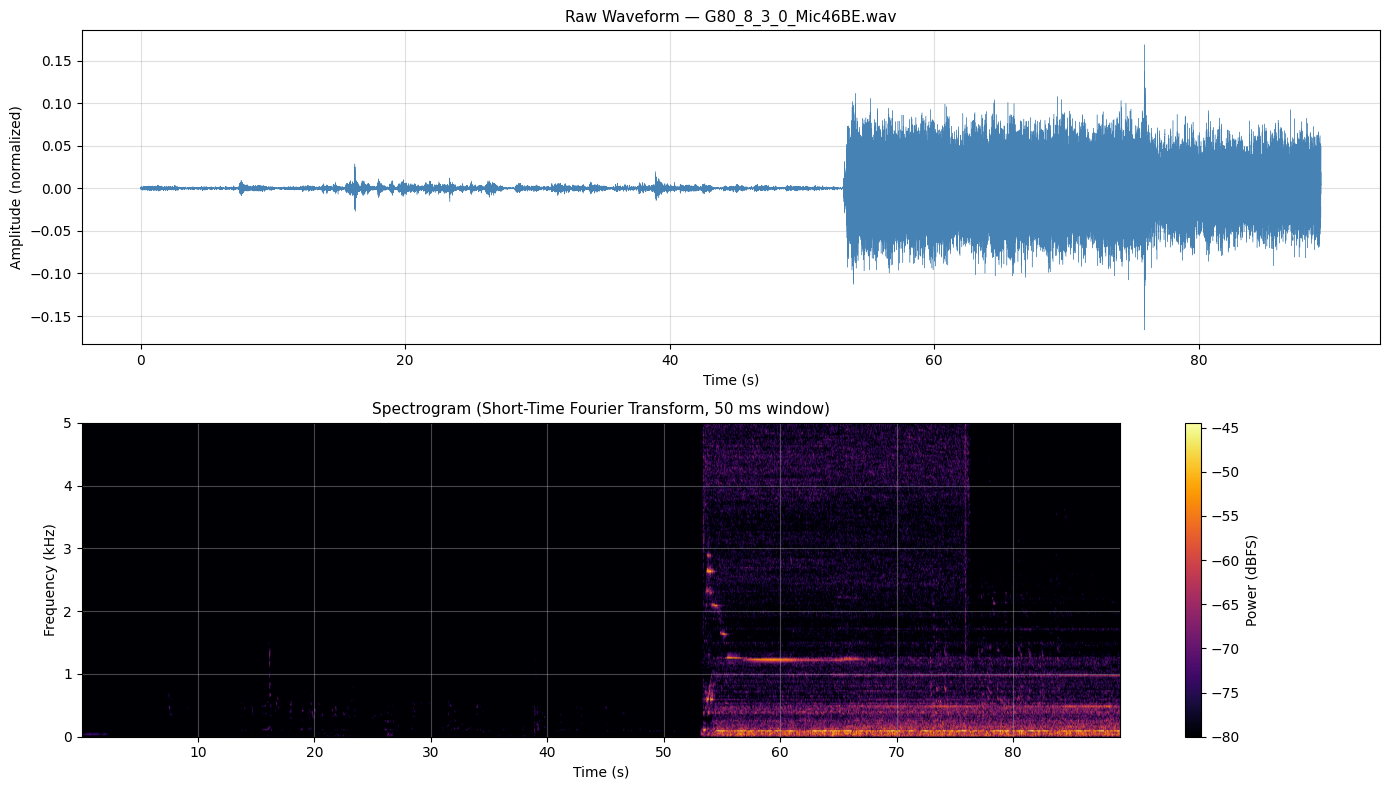

In [4]:
t = np.arange(len(signal)) / fs  # Absolute time vector (s)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Waveform ──────────────────────────────────────────────────────────────────
axes[0].plot(t, signal, lw=0.3, color='steelblue')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (normalized)')
axes[0].set_title(f'Raw Waveform — {EXAMPLE_WAV.name}')

# ── Spectrogram ───────────────────────────────────────────────────────────────
# 50 ms window gives a good time–frequency trade-off at 96 kHz
nperseg = int(0.05 * fs)
f_spec, t_spec, Sxx = sp_spectrogram(signal, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

# Limit frequency axis to 5 kHz (or Nyquist if lower) for readability
f_max_khz = min(fs / 2000, 5.0)
f_mask = f_spec <= f_max_khz * 1000

im = axes[1].pcolormesh(
    t_spec, f_spec[f_mask] / 1000,
    10 * np.log10(Sxx[f_mask] + 1e-12),
    shading='gouraud', cmap='inferno', vmin=-80
)
plt.colorbar(im, ax=axes[1], label='Power (dBFS)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].set_title('Spectrogram (Short-Time Fourier Transform, 50 ms window)')

plt.tight_layout()
plt.show()


## 2. Blast Detection

The blasting process begins when the operator opens the abrasive valve.
The first **6–8 seconds** contain a startup transient:
nozzle purge, valve opening noise, and pressure stabilisation.
Only after this period does the **useful steady-state signal** begin.

### Algorithm: Short-Time Energy Threshold

1. Divide the signal into short frames of `ENERGY_WINDOW_S` seconds.
2. Compute the **Root Mean Square (RMS)** energy of each frame:
   `E_k = sqrt( mean( x[k*hop : (k+1)*hop]^2 ) )`
3. Estimate the **noise floor** from the first `NOISE_DURATION_S` seconds.
4. Detect the **onset** as the first frame where:
   `E_k > ONSET_THRESHOLD * noise_floor`
5. The **useful signal** starts at: `t_onset + ONSET_OFFSET_S`

### Why 7 s offset?
The mentor specifies a 6–8 s startup window.
We use the midpoint (7 s) as a robust default;
this can be adjusted in the configuration cell above.


In [5]:
def detect_blast_onset(signal, fs, energy_window_s=0.05, noise_duration_s=0.5, threshold=10.0):
    """
    Detect the onset of the blasting process using short-time RMS energy.

    Parameters
    ----------
    signal : ndarray
        Normalized audio signal.
    fs : int
        Sampling rate (Hz).
    energy_window_s : float
        Duration of each short-time energy frame (s).
    noise_duration_s : float
        Duration of the initial quiet region used to estimate the noise floor (s).
    threshold : float
        Onset is declared when frame energy exceeds (threshold × noise_floor).

    Returns
    -------
    onset_sample : int
        Sample index of the detected onset.
    onset_time : float
        Time (s) of the detected onset.
    frame_times : ndarray
        Time vector for the energy frames.
    rms_energy : ndarray
        RMS energy of each frame.
    noise_floor : float
        Estimated RMS of the background noise.
    """
    hop      = int(energy_window_s * fs)
    n_frames = len(signal) // hop

    # Compute RMS energy for each short frame
    rms_energy = np.array([
        np.sqrt(np.mean(signal[i * hop : (i + 1) * hop] ** 2))
        for i in range(n_frames)
    ])
    frame_times = np.arange(n_frames) * energy_window_s

    # Noise floor: mean RMS of the initial quiet segment
    noise_frames = max(1, int(noise_duration_s / energy_window_s))
    noise_floor  = np.mean(rms_energy[:noise_frames])

    # First frame exceeding the threshold marks the onset
    above = np.where(rms_energy > threshold * noise_floor)[0]
    if len(above) == 0:
        # Fallback: use the frame with maximum energy
        onset_frame = int(np.argmax(rms_energy))
        print("Warning: threshold never exceeded — using peak energy frame as onset.")
    else:
        onset_frame = int(above[0])

    onset_sample = onset_frame * hop
    onset_time   = onset_frame * energy_window_s

    return onset_sample, onset_time, frame_times, rms_energy, noise_floor


onset_sample, onset_time, frame_times, rms_energy, noise_floor = detect_blast_onset(
    signal, fs,
    energy_window_s  = ENERGY_WINDOW_S,
    noise_duration_s = NOISE_DURATION_S,
    threshold        = ONSET_THRESHOLD,
)

# Useful signal begins ONSET_OFFSET_S seconds after the detected onset
useful_start_time   = onset_time + ONSET_OFFSET_S
useful_start_sample = int(useful_start_time * fs)
useful_signal       = signal[useful_start_sample:]

print(f"Noise floor (RMS)    : {noise_floor:.6f}")
print(f"Threshold level      : {ONSET_THRESHOLD * noise_floor:.6f}")
print(f"Blast onset          : {onset_time:.3f} s  (sample {onset_sample:,})")
print(f"Useful signal from   : {useful_start_time:.3f} s  (onset + {ONSET_OFFSET_S} s)")
print(f"Useful signal length : {len(useful_signal) / fs:.2f} s  ({len(useful_signal):,} samples)")


Noise floor (RMS)    : 0.001098
Threshold level      : 0.010980
Blast onset          : 53.350 s  (sample 2,560,800)
Useful signal from   : 60.350 s  (onset + 7.0 s)
Useful signal length : 28.90 s  (1,386,993 samples)


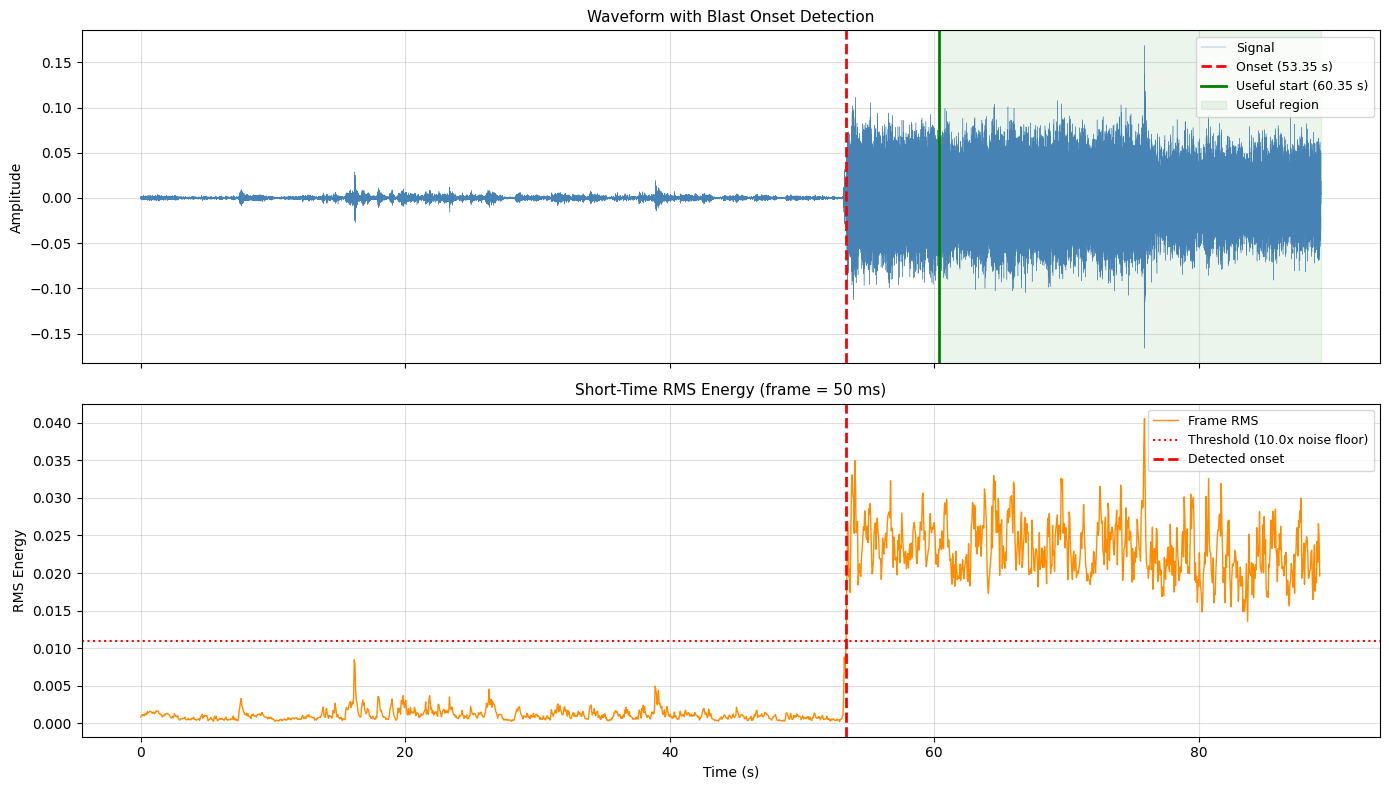

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Waveform with onset markers ───────────────────────────────────────────────
ax1.plot(t, signal, lw=0.3, color='steelblue', label='Signal')
ax1.axvline(onset_time,        color='red',   lw=2, ls='--', label=f'Onset ({onset_time:.2f} s)')
ax1.axvline(useful_start_time, color='green', lw=2, ls='-',  label=f'Useful start ({useful_start_time:.2f} s)')
ax1.axvspan(useful_start_time, t[-1], alpha=0.08, color='green', label='Useful region')
ax1.set_ylabel('Amplitude')
ax1.set_title('Waveform with Blast Onset Detection')
ax1.legend(loc='upper right', fontsize=9)

# ── Short-time RMS energy ─────────────────────────────────────────────────────
ax2.plot(frame_times, rms_energy, color='darkorange', lw=1, label='Frame RMS')
ax2.axhline(ONSET_THRESHOLD * noise_floor, color='red', ls=':', lw=1.5,
            label=f'Threshold ({ONSET_THRESHOLD}x noise floor)')
ax2.axvline(onset_time, color='red', lw=2, ls='--', label='Detected onset')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('RMS Energy')
ax2.set_title(f'Short-Time RMS Energy (frame = {ENERGY_WINDOW_S*1000:.0f} ms)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Floating Analysis Windows

All calculations are performed on **short overlapping segments** of the useful signal,
not on the entire recording. This approach:

- Tracks the temporal evolution of signal properties during blasting
- Reduces the influence of isolated transients
- Allows statistical comparison across multiple windows

### Window Parameters
| Parameter | Value | Description |
|-----------|-------|-------------|
| `WINDOW_DURATION_S` | 5 s | Length of each analysis window |
| `WINDOW_STEP_S` | 1 s | Step between consecutive window starts |
| Overlap | 80 % | `(1 − step/duration) × 100` |

Windows are extracted exclusively from the **useful signal region**,
i.e., from `onset_time + ONSET_OFFSET_S` onwards.


In [7]:
def create_floating_windows(signal, fs, window_s, step_s):
    """
    Generate overlapping (floating) analysis windows from a signal.

    Parameters
    ----------
    signal : ndarray
        Input signal (useful portion only).
    fs : int
        Sampling rate (Hz).
    window_s : float
        Window length in seconds (5–10 s recommended).
    step_s : float
        Step between consecutive window starts (s).

    Returns
    -------
    windows : list of ndarray
        List of equal-length signal segments.
    window_start_times : ndarray
        Start time (s) of each window relative to the start of `signal`.
    """
    win_len  = int(window_s * fs)
    step_len = int(step_s * fs)

    # Number of complete windows that fit in the signal
    n_wins = max(0, (len(signal) - win_len) // step_len + 1)

    windows            = [signal[i * step_len : i * step_len + win_len] for i in range(n_wins)]
    window_start_times = np.arange(n_wins) * step_s

    return windows, window_start_times


windows, window_starts = create_floating_windows(
    useful_signal, fs, WINDOW_DURATION_S, WINDOW_STEP_S
)

overlap_pct = (1 - WINDOW_STEP_S / WINDOW_DURATION_S) * 100

print(f"Window length    : {WINDOW_DURATION_S} s  ({int(WINDOW_DURATION_S * fs):,} samples)")
print(f"Step size        : {WINDOW_STEP_S} s  ({int(WINDOW_STEP_S * fs):,} samples)")
print(f"Overlap          : {overlap_pct:.0f} %")
print(f"Number of windows: {len(windows)}")


Window length    : 5.0 s  (240,000 samples)
Step size        : 1.0 s  (48,000 samples)
Overlap          : 80 %
Number of windows: 24


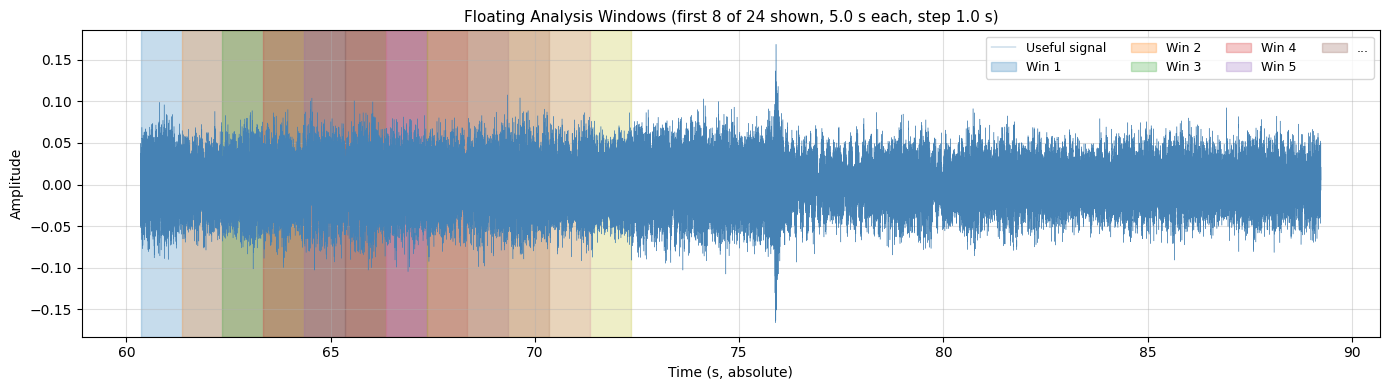

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

t_useful   = np.arange(len(useful_signal)) / fs
t_useful_abs = t_useful + useful_start_time  # Absolute time axis

ax.plot(t_useful_abs, useful_signal, lw=0.3, color='steelblue', label='Useful signal')

# Highlight the first 8 windows with distinct colors
n_show = min(len(windows), 8)
colors = plt.cm.tab10(np.linspace(0, 0.8, n_show))
for i in range(n_show):
    abs_start = useful_start_time + window_starts[i]
    abs_end   = abs_start + WINDOW_DURATION_S
    ax.axvspan(abs_start, abs_end, alpha=0.25, color=colors[i],
               label=f'Win {i+1}' if i < 5 else ('...' if i == 5 else None))

ax.set_xlabel('Time (s, absolute)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Floating Analysis Windows (first {n_show} of {len(windows)} shown, '
             f'{WINDOW_DURATION_S} s each, step {WINDOW_STEP_S} s)')
ax.legend(loc='upper right', ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Bandpass Filter Design

### Filter Type Overview

| Type | Passband | Stopband | Group Delay | Selectivity | Typical Use |
|------|----------|----------|-------------|-------------|-------------|
| **Butterworth** | Maximally flat (monotone) | Monotone | Moderate distortion | Moderate | Reference / baseline |
| **Chebyshev I** | Equiripple (±rp dB) | Monotone | Significant distortion | Good | Sharper cutoff than Butterworth |
| **Chebyshev II** | Monotone | Equiripple (–rs dB) | Moderate distortion | Good | Flat passband; notches in stopband |
| **Elliptical** | Equiripple (±rp dB) | Equiripple (–rs dB) | Significant distortion | Best | Steepest rolloff for given order |
| **Bessel** | Monotone | Gradual rolloff | **Linear** (constant) | Poor | Best phase fidelity; transient accuracy |

### Design Parameters
- **Chebyshev I passband ripple**: 0.5 dB (`CHEBY1_RIPPLE_DB`)
- **Chebyshev II stopband attenuation**: 40 dB (`CHEBY2_ATTEN_DB`)
- **Elliptical passband ripple / stopband attenuation**: 0.5 dB / 40 dB

### Implementation
All filters use **Second-Order Sections (SOS)** for numerical stability.
`sosfiltfilt` performs **zero-phase** (forward + backward) filtering,
which doubles the effective order and eliminates phase distortion at the cost of 2× computation.

Cutoff frequencies are normalized to the Nyquist frequency:
`Wn = [f_low / (fs/2),  f_high / (fs/2)]`


In [9]:
def design_bandpass_filter(filter_type, order, low_hz, high_hz, fs):
    """
    Design a digital bandpass filter in SOS (Second-Order Sections) form.

    Parameters
    ----------
    filter_type : str
        Filter family: 'Butterworth', 'Chebyshev I', 'Chebyshev II',
        'Elliptical', or 'Bessel'.
    order : int
        Filter order (3, 5, or 7). The resulting bandpass doubles the pole count,
        so a 3rd-order prototype yields a 6th-order bandpass.
    low_hz : float
        Lower 3 dB cutoff frequency (Hz). For Chebyshev/Elliptical, this is
        the edge of the ripple band.
    high_hz : float
        Upper 3 dB cutoff frequency (Hz).
    fs : int
        Sampling rate (Hz).

    Returns
    -------
    sos : ndarray, shape (n_sections, 6)
        SOS matrix. Each row is [b0, b1, b2, 1, a1, a2] for one biquad.
    """
    nyq = fs / 2.0
    Wn  = [low_hz / nyq, high_hz / nyq]

    if filter_type == 'Butterworth':
        sos = butter(order, Wn, btype='bandpass', output='sos')

    elif filter_type == 'Chebyshev I':
        # rp: maximum ripple in the passband (dB)
        sos = cheby1(order, CHEBY1_RIPPLE_DB, Wn, btype='bandpass', output='sos')

    elif filter_type == 'Chebyshev II':
        # rs: minimum attenuation in the stopband (dB)
        sos = cheby2(order, CHEBY2_ATTEN_DB, Wn, btype='bandpass', output='sos')

    elif filter_type == 'Elliptical':
        # rp: passband ripple (dB); rs: stopband attenuation (dB)
        sos = ellip(order, ELLIP_RIPPLE_DB, ELLIP_ATTEN_DB, Wn, btype='bandpass', output='sos')

    elif filter_type == 'Bessel':
        # norm='phase': the cutoff frequencies define the -3 dB point of the group delay
        sos = bessel(order, Wn, btype='bandpass', output='sos', norm='phase')

    else:
        raise ValueError(f"Unknown filter type: '{filter_type}'")

    return sos


def filter_complexity(sos):
    """
    Estimate the number of arithmetic operations per output sample for a SOS filter.

    For Direct Form II Transposed, each 2nd-order section requires:
    - 5 multiplications (b0, b1, b2, a1, a2)  — a0 = 1 is implicit
    - 4 additions

    Parameters
    ----------
    sos : ndarray, shape (n_sections, 6)

    Returns
    -------
    dict
        Keys: n_sections, multiplications, additions, total_operations.
    """
    n = len(sos)
    return {
        'n_sections'      : n,
        'multiplications' : 5 * n,
        'additions'       : 4 * n,
        'total_operations': 9 * n,   # per output sample, single pass
    }


# Pre-design and cache all (filter_type, order, band) combinations
filter_cache  = {}
design_errors = []

for ftype, order, (lo, hi) in product(FILTER_TYPES, FILTER_ORDERS, zip(LOWER_LIMITS, UPPER_LIMITS)):
    key = (ftype, order, lo, hi)
    try:
        filter_cache[key] = design_bandpass_filter(ftype, order, lo, hi, fs)
    except Exception as e:
        design_errors.append(f"{ftype} N={order} band {lo}–{hi} Hz: {e}")
        filter_cache[key] = None

n_ok   = sum(v is not None for v in filter_cache.values())
n_fail = len(design_errors)

print(f"Filters designed successfully : {n_ok}")
print(f"Design failures               : {n_fail}")
for err in design_errors[:10]:
    print(f"  FAIL: {err}")


Filters designed successfully : 225
Design failures               : 0


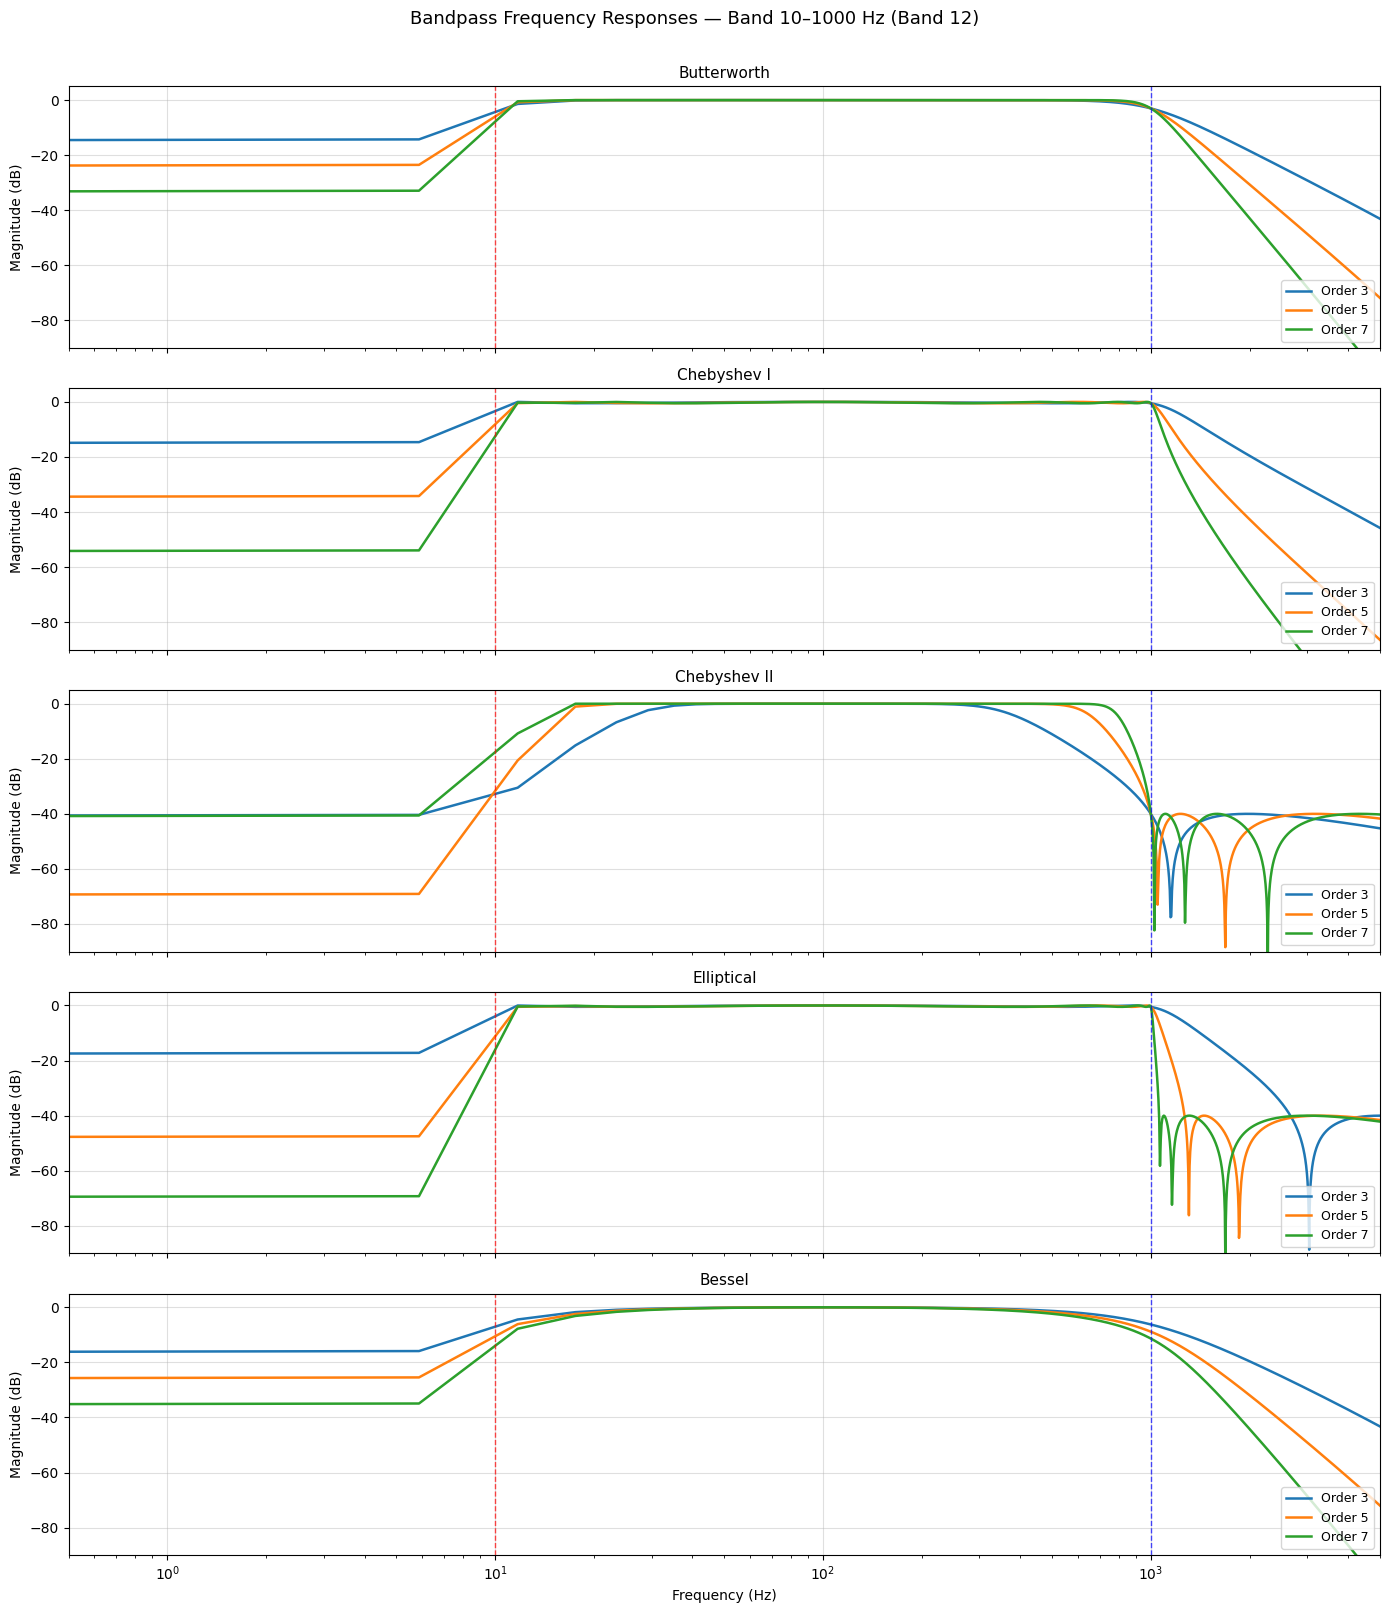

In [10]:
# Plot frequency responses for one representative band (band 11: 10–1000 Hz)
# to compare all filter types at all orders
DEMO_BAND = 11                         # band index to visualise
lo_demo   = LOWER_LIMITS[DEMO_BAND]
hi_demo   = UPPER_LIMITS[DEMO_BAND]
N_PTS     = 4096                       # frequency-axis resolution

fig, axes = plt.subplots(len(FILTER_TYPES), 1, figsize=(14, 16), sharex=True)

for ax, ftype in zip(axes, FILTER_TYPES):
    for order in FILTER_ORDERS:
        sos = filter_cache.get((ftype, order, lo_demo, hi_demo))
        if sos is None:
            continue
        w, h = sosfreqz(sos, worN=N_PTS, fs=fs)
        ax.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'Order {order}', lw=1.8)

    ax.axvline(lo_demo, color='red',  ls='--', lw=1, alpha=0.7)
    ax.axvline(hi_demo, color='blue', ls='--', lw=1, alpha=0.7)
    ax.set_xlim(lo_demo * 0.05, hi_demo * 5)
    ax.set_ylim(-90, 5)
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(ftype)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xscale('log')

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(f'Bandpass Frequency Responses — Band {lo_demo}–{hi_demo} Hz (Band {DEMO_BAND+1})',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


## 5. Signal Parameter Extraction

For each filtered window, six parameters are computed:

| Parameter | Formula | Physical Meaning |
|-----------|---------|-----------------|
| **RMS** | `sqrt( mean(x²) )` | Signal power; proportional to energy density |
| **Peak** | `max|x|` | Maximum instantaneous amplitude |
| **Crest Factor** | `Peak / RMS` | Impulsiveness; high CF = spike-dominated signal |
| **Zero Crossing Rate** | `(count of sign changes) / (2 × duration)` | Proxy for dominant frequency |
| **Band Power** | `trapz(PSD, f)` via Welch | Spectral energy concentrated in the passband |
| **Spectral Centroid** | `sum(f·S) / sum(S)` | Frequency centre-of-mass of the spectrum |

### Why these parameters?
- **RMS & Peak**: fundamental energy/amplitude descriptors used in acoustics and vibration analysis
- **Crest Factor**: distinguishes continuous blasting noise (low CF) from abrasive impact transients (high CF)
- **ZCR**: simple spectral feature; correlates with the dominant pitch band
- **Band Power & Centroid**: spectral shape descriptors useful for comparing frequency bands


In [11]:
def compute_parameters(x, fs):
    """
    Compute six signal descriptors for a filtered analysis window.

    Parameters
    ----------
    x : ndarray
        Filtered signal window (output of sosfiltfilt).
    fs : int
        Sampling rate (Hz).

    Returns
    -------
    dict with keys:
        rms, peak, crest_factor, zcr, band_power, spectral_centroid.
    """
    # ── RMS: Root Mean Square ──────────────────────────────────────────────────
    rms = np.sqrt(np.mean(x ** 2))

    # ── Peak: maximum absolute amplitude ──────────────────────────────────────
    peak = float(np.max(np.abs(x)))

    # ── Crest Factor: peak-to-RMS ratio ───────────────────────────────────────
    crest_factor = peak / rms if rms > 1e-12 else 0.0

    # ── Zero Crossing Rate: sign changes per second ────────────────────────────
    # Factor of 2 because each full cycle has two zero crossings
    signs = np.sign(x)
    n_crossings = np.sum(np.abs(np.diff(signs)) > 0)
    zcr = n_crossings / (2.0 * (len(x) - 1) / fs)

    # ── Power Spectral Density via Welch's method ─────────────────────────────
    # nperseg = 1024 samples gives frequency resolution of fs/1024
    nperseg = min(1024, len(x) // 4)
    f_psd, psd = welch(x, fs=fs, nperseg=nperseg, window='hann')

    # Band Power: integral of PSD over all frequencies (trapezoidal rule)
    band_power = float(np.trapz(psd, f_psd))

    # Spectral Centroid: frequency weighted by PSD amplitude
    psd_sum = np.sum(psd)
    spectral_centroid = float(np.sum(f_psd * psd) / psd_sum) if psd_sum > 0 else 0.0

    return {
        'rms'              : float(rms),
        'peak'             : peak,
        'crest_factor'     : crest_factor,
        'zcr'              : zcr,
        'band_power'       : band_power,
        'spectral_centroid': spectral_centroid,
    }


In [12]:
# ── Main Analysis Loop ────────────────────────────────────────────────────────
# For each combination of (window, filter_type, order, frequency_band):
#   1. Apply the pre-designed bandpass filter (zero-phase via sosfiltfilt)
#   2. Compute the six signal parameters on the filtered output
#   3. Record the filter computation time for complexity comparison

n_combos = len(windows) * len(FILTER_TYPES) * len(FILTER_ORDERS) * N_BANDS
print(f"Running analysis...")
print(f"  {len(windows)} windows x {len(FILTER_TYPES)} filter types x "
      f"{len(FILTER_ORDERS)} orders x {N_BANDS} bands = {n_combos:,} combinations")

results = []    # accumulates one dict per (window, filter, order, band)
timing  = {}    # (filter_type, order, band_idx) -> mean filter time (s)

for ftype in FILTER_TYPES:
    for order in FILTER_ORDERS:
        for band_idx, (lo, hi) in enumerate(zip(LOWER_LIMITS, UPPER_LIMITS)):
            sos = filter_cache.get((ftype, order, lo, hi))
            if sos is None:
                continue

            filter_times = []

            for win_idx, window in enumerate(windows):
                # Time the filtering step only (not parameter extraction)
                t0 = time.perf_counter()
                x_filtered = sosfiltfilt(sos, window)  # zero-phase filtering
                t1 = time.perf_counter()
                filter_times.append(t1 - t0)

                params = compute_parameters(x_filtered, fs)

                results.append({
                    'filter_type'    : ftype,
                    'order'          : order,
                    'band_idx'       : band_idx,
                    'band_label'     : BAND_LABELS[band_idx],
                    'low_hz'         : lo,
                    'high_hz'        : hi,
                    'window_idx'     : win_idx,
                    'window_start_s' : window_starts[win_idx] + useful_start_time,
                    **params,
                })

            timing[(ftype, order, band_idx)] = float(np.mean(filter_times))

df = pd.DataFrame(results)
print(f"\nAnalysis complete. Result rows: {len(df):,}")
df.head(3)


Running analysis...
  24 windows x 5 filter types x 3 orders x 15 bands = 5,400 combinations



Analysis complete. Result rows: 5,400


,filter_type,order,band_idx,band_label,low_hz,high_hz,window_idx,window_start_s,rms,peak,crest_factor,zcr,band_power,spectral_centroid
0,Butterworth,3,0,176–225 Hz,176,225,0,60.35,0.002610,0.009471,3.628740,197.300822,0.000007,197.267473
1,Butterworth,3,0,176–225 Hz,176,225,1,61.35,0.002676,0.011503,4.297868,196.700820,0.000007,196.886955
2,Butterworth,3,0,176–225 Hz,176,225,2,62.35,0.002830,0.011506,4.065628,198.400827,0.000008,197.321322


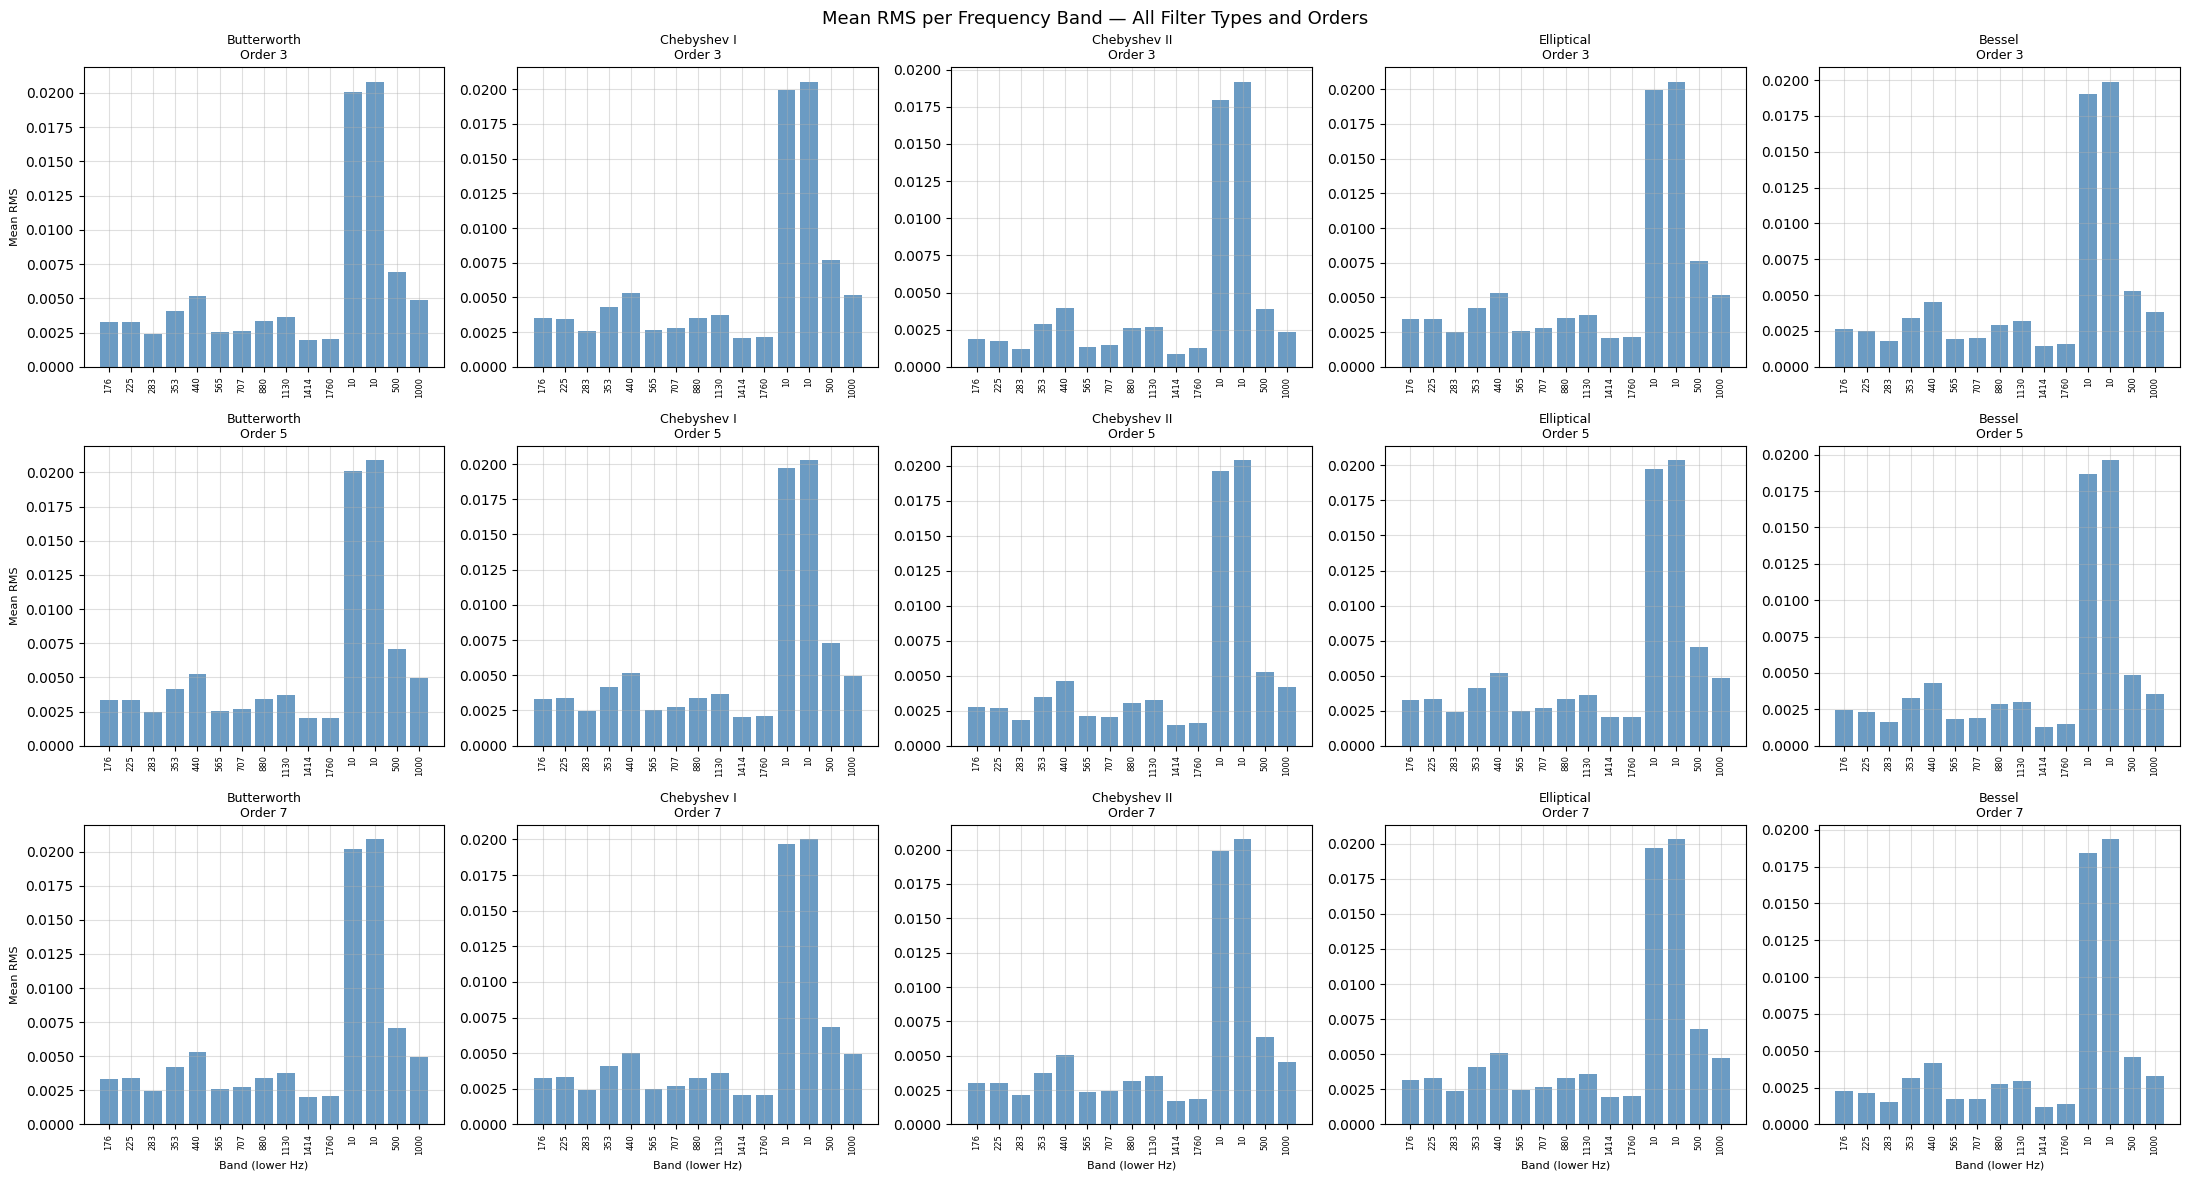

In [13]:
# Mean RMS across all windows for each (filter type, order) combination per band
fig, axes = plt.subplots(len(FILTER_ORDERS), len(FILTER_TYPES),
                         figsize=(22, 12), sharey=False)

for row, order in enumerate(FILTER_ORDERS):
    for col, ftype in enumerate(FILTER_TYPES):
        ax = axes[row, col]
        subset   = df[(df.filter_type == ftype) & (df.order == order)]
        mean_rms = subset.groupby('band_idx')['rms'].mean()
        values   = mean_rms.reindex(range(N_BANDS), fill_value=0.0)

        ax.bar(range(N_BANDS), values, color='steelblue', alpha=0.8)
        ax.set_title(f'{ftype}\nOrder {order}', fontsize=9)
        ax.set_xticks(range(N_BANDS))
        ax.set_xticklabels([f'{lo}' for lo in LOWER_LIMITS], rotation=90, fontsize=6)

        if col == 0:
            ax.set_ylabel('Mean RMS', fontsize=8)
        if row == len(FILTER_ORDERS) - 1:
            ax.set_xlabel('Band (lower Hz)', fontsize=8)

fig.suptitle('Mean RMS per Frequency Band — All Filter Types and Orders', fontsize=13)
plt.tight_layout()
plt.show()


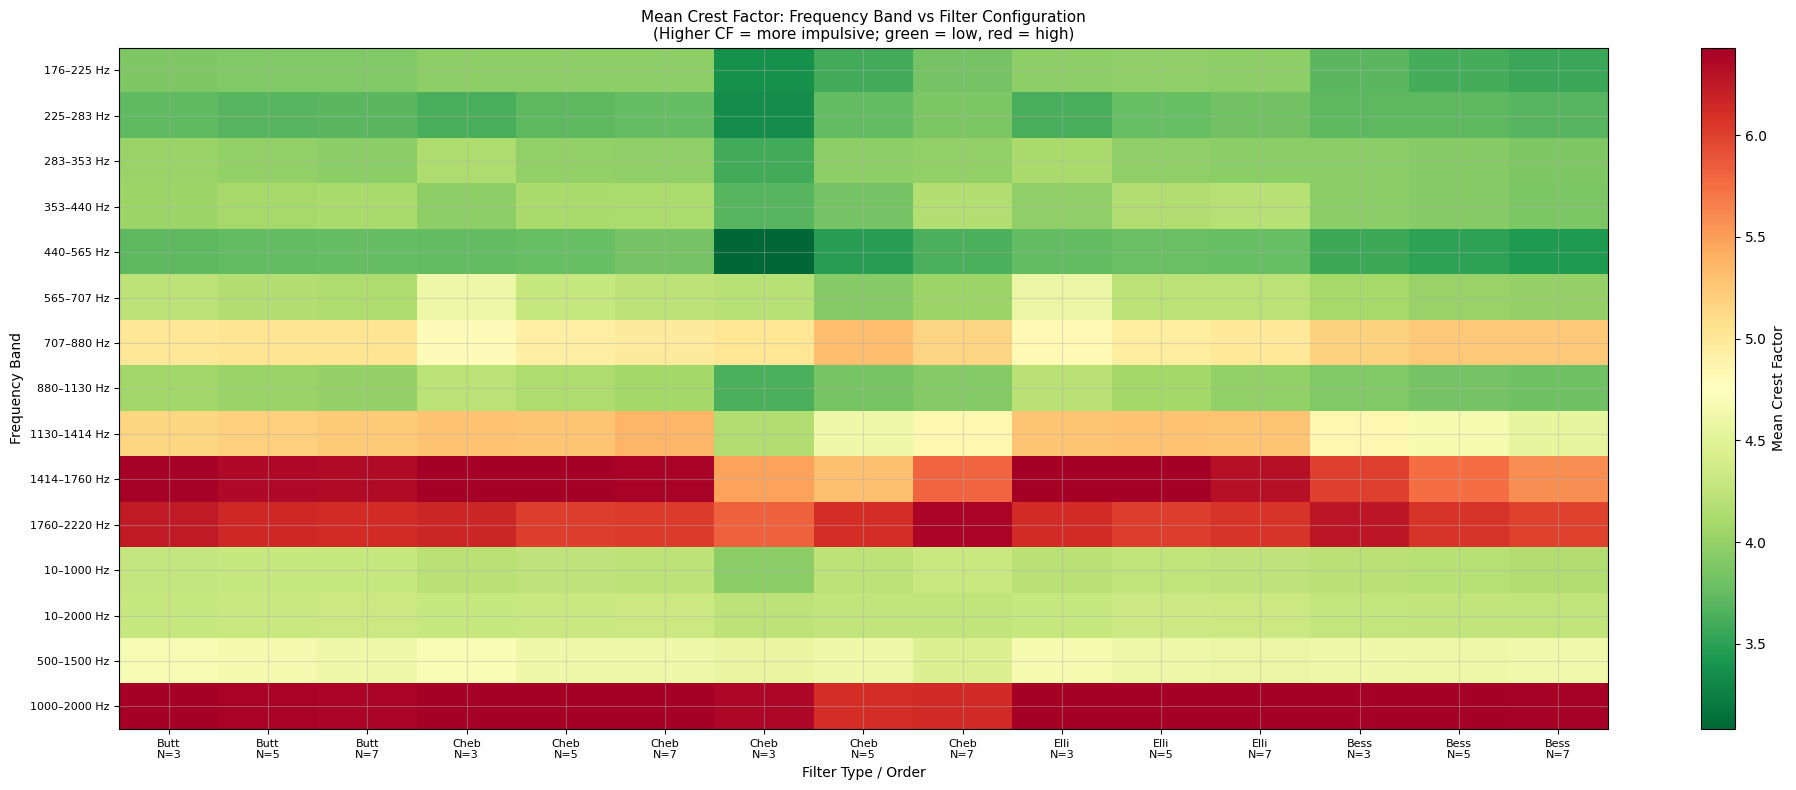

In [14]:
# Heatmap: mean crest factor (Rows = bands, Columns = filter type + order)
combo_labels = [f"{ft[:4]}\nN={o}" for ft, o in product(FILTER_TYPES, FILTER_ORDERS)]
n_combos_hm  = len(FILTER_TYPES) * len(FILTER_ORDERS)
cf_matrix    = np.full((N_BANDS, n_combos_hm), np.nan)

for col, (ftype, order) in enumerate(product(FILTER_TYPES, FILTER_ORDERS)):
    for row in range(N_BANDS):
        sub = df[(df.filter_type == ftype) & (df.order == order) & (df.band_idx == row)]
        if len(sub) > 0:
            cf_matrix[row, col] = sub['crest_factor'].mean()

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(cf_matrix, aspect='auto', cmap='RdYlGn_r', interpolation='nearest',
               vmin=np.nanmin(cf_matrix), vmax=np.nanpercentile(cf_matrix, 95))
plt.colorbar(im, ax=ax, label='Mean Crest Factor')

ax.set_xticks(range(n_combos_hm))
ax.set_xticklabels(combo_labels, fontsize=8)
ax.set_yticks(range(N_BANDS))
ax.set_yticklabels(BAND_LABELS, fontsize=8)
ax.set_xlabel('Filter Type / Order')
ax.set_ylabel('Frequency Band')
ax.set_title('Mean Crest Factor: Frequency Band vs Filter Configuration\n'
             '(Higher CF = more impulsive; green = low, red = high)')
plt.tight_layout()
plt.show()


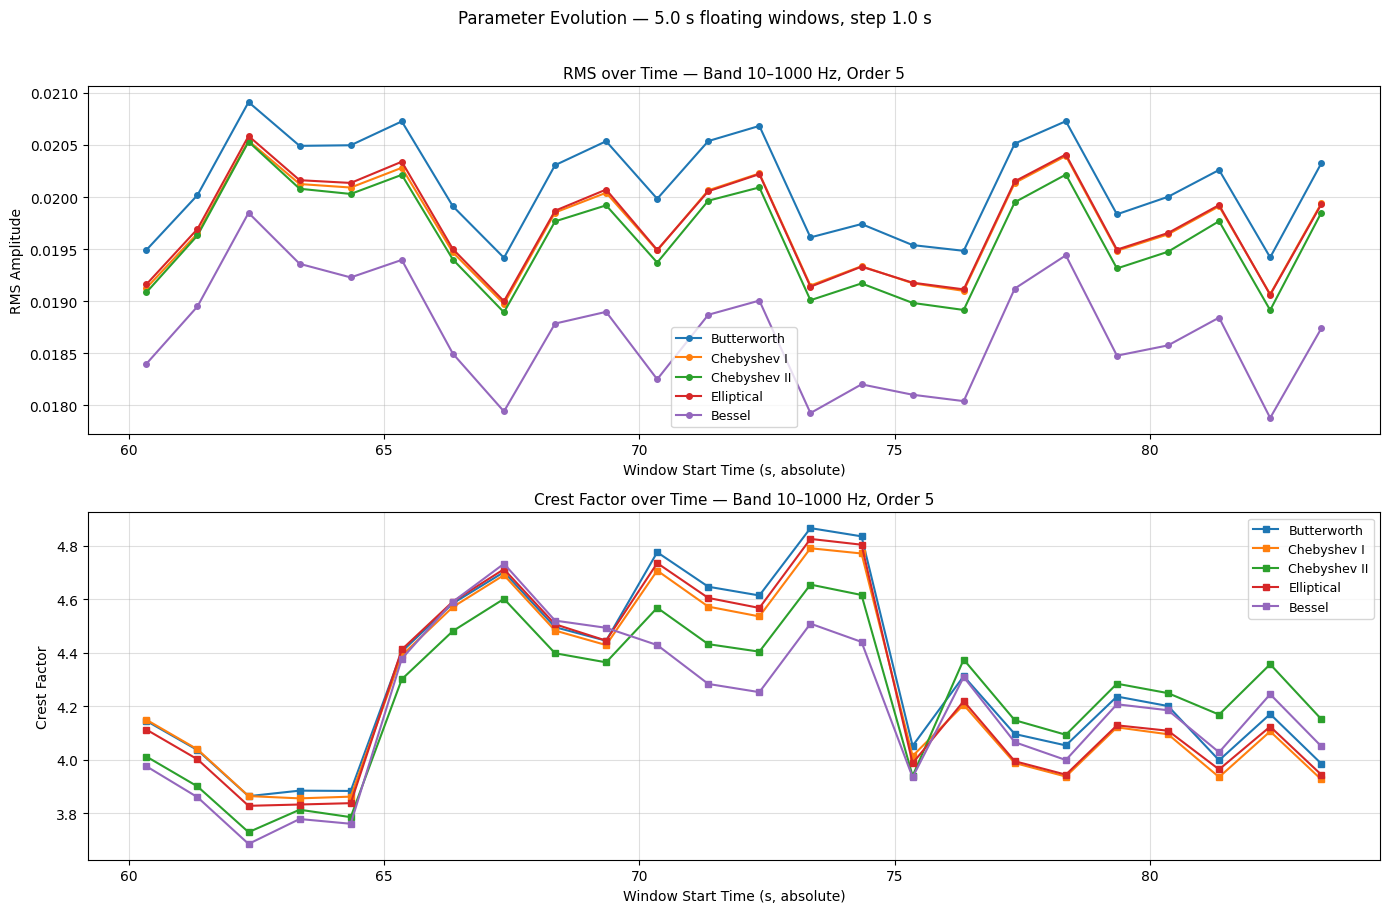

In [15]:
# RMS evolution over time for a selected band — one line per filter type
FOCUS_BAND  = 11  # band index: 10–1000 Hz (broadband)
FOCUS_ORDER = 5

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ftype in FILTER_TYPES:
    sub = df[
        (df.filter_type == ftype) &
        (df.order == FOCUS_ORDER) &
        (df.band_idx == FOCUS_BAND)
    ].sort_values('window_start_s')

    axes[0].plot(sub['window_start_s'], sub['rms'],
                 marker='o', markersize=4, lw=1.5, label=ftype)
    axes[1].plot(sub['window_start_s'], sub['crest_factor'],
                 marker='s', markersize=4, lw=1.5, label=ftype)

for ax, ylabel, title in zip(
    axes,
    ['RMS Amplitude', 'Crest Factor'],
    [f'RMS over Time — Band {BAND_LABELS[FOCUS_BAND]}, Order {FOCUS_ORDER}',
     f'Crest Factor over Time — Band {BAND_LABELS[FOCUS_BAND]}, Order {FOCUS_ORDER}']
):
    ax.set_xlabel('Window Start Time (s, absolute)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle(f'Parameter Evolution — {WINDOW_DURATION_S} s floating windows, '
             f'step {WINDOW_STEP_S} s', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 6. Complexity and Reliability Comparison

### Computational Complexity

For a filter in SOS form, each biquad (2nd-order section) needs:
- **5 multiplications**: b0, b1, b2, a1, a2  (a0 = 1, no multiply needed)
- **4 additions**
- Total: **9 arithmetic operations per output sample per section**

An N-th order bandpass filter has `ceil(N)` sections (the bandpass transformation doubles the
prototype order, so a 3rd-order prototype → 3 SOS sections → 27 ops/sample).

`sosfiltfilt` runs **two passes** (forward + backward) for zero-phase output,
so the effective cost is **2 × 9 × n_sections** ops/sample.

### Reliability Metrics
We quantify reliability along three dimensions:

| Metric | Meaning | Better |
|--------|---------|--------|
| **RMS Coefficient of Variation (CV)** | std(RMS) / mean(RMS) across windows | Lower |
| **Mean filter time** | Measured wall-clock time per window | Lower |
| **Passband ripple** | From design parameters (dB) | Lower |

Low CV means the filter produces consistent estimates across different windows —
a sign that it reliably captures the physical signal rather than artefacts.


In [16]:
complexity_rows = []

for ftype, order in product(FILTER_TYPES, FILTER_ORDERS):
    # Use the first valid band to count SOS sections (same for all bands at same type+order)
    sos = next(
        (filter_cache.get((ftype, order, lo, hi))
         for lo, hi in zip(LOWER_LIMITS, UPPER_LIMITS)
         if filter_cache.get((ftype, order, lo, hi)) is not None),
        None
    )
    if sos is None:
        continue

    cx = filter_complexity(sos)

    # sosfiltfilt = 2 passes, so double the per-sample operations
    ops_single   = cx['total_operations']
    ops_filtfilt = 2 * ops_single

    # Mean filter time averaged across all bands and windows
    avg_time_ms = np.nanmean([
        timing.get((ftype, order, b), np.nan) * 1000.0
        for b in range(N_BANDS)
    ])

    # RMS Coefficient of Variation across all windows and bands
    subset = df[(df.filter_type == ftype) & (df.order == order)]
    rms_mean = subset['rms'].mean()
    rms_cv   = (subset['rms'].std() / rms_mean) if rms_mean > 0 else np.nan

    # Passband ripple from design configuration
    ripple_map = {
        'Butterworth'  : 0.0,              # maximally flat — effectively 0 dB ripple
        'Chebyshev I'  : CHEBY1_RIPPLE_DB,
        'Chebyshev II' : 0.0,              # flat passband
        'Elliptical'   : ELLIP_RIPPLE_DB,
        'Bessel'       : 0.0,              # monotone
    }

    complexity_rows.append({
        'Filter Type'           : ftype,
        'Order'                 : order,
        'SOS Sections'          : cx['n_sections'],
        'Ops/Sample (1 pass)'   : ops_single,
        'Ops/Sample (filtfilt)' : ops_filtfilt,
        'Mean Time/Window (ms)' : round(avg_time_ms, 3),
        'RMS CV'                : round(rms_cv, 4),
        'Passband Ripple (dB)'  : ripple_map[ftype],
    })

df_cx = pd.DataFrame(complexity_rows)
df_cx = df_cx.sort_values(['Order', 'Ops/Sample (filtfilt)']).reset_index(drop=True)

print("=== Computational Complexity and Reliability ===")
print(df_cx.to_string(index=False))


=== Computational Complexity and Reliability ===
 Filter Type  Order  SOS Sections  Ops/Sample (1 pass)  Ops/Sample (filtfilt)  Mean Time/Window (ms)  RMS CV  Passband Ripple (dB)
 Butterworth      3             3                   27                     54                  6.486  1.0207                   0.0
 Chebyshev I      3             3                   27                     54                  6.178  0.9733                   0.5
Chebyshev II      3             3                   27                     54                  6.227  1.3022                   0.0
  Elliptical      3             3                   27                     54                  6.331  0.9767                   0.5
      Bessel      3             3                   27                     54                  6.105  1.1364                   0.0
 Butterworth      5             5                   45                     90                  7.355  1.0101                   0.0
 Chebyshev I      5             5 

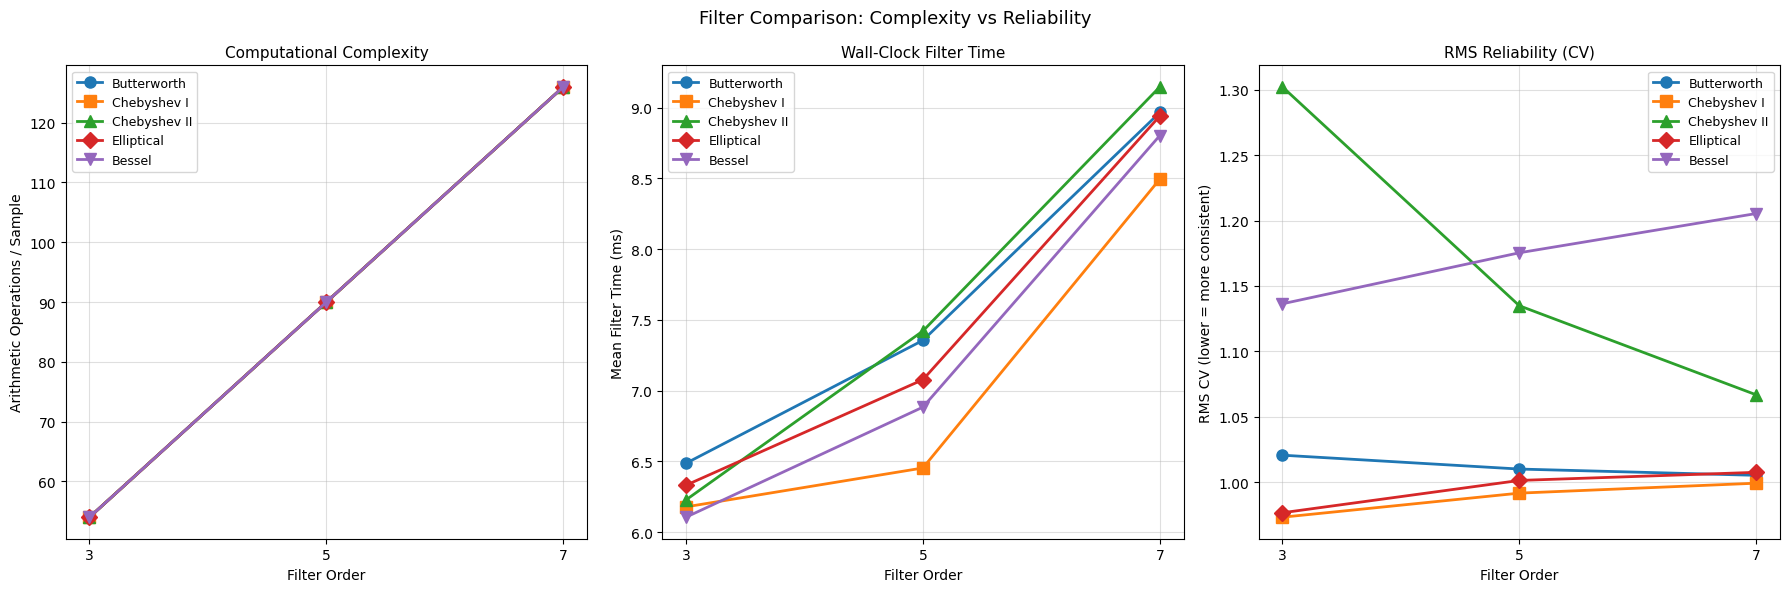

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markers = {'Butterworth': 'o', 'Chebyshev I': 's', 'Chebyshev II': '^',
           'Elliptical': 'D', 'Bessel': 'v'}
colors  = {'Butterworth': '#1f77b4', 'Chebyshev I': '#ff7f0e', 'Chebyshev II': '#2ca02c',
           'Elliptical': '#d62728', 'Bessel': '#9467bd'}

for ftype in FILTER_TYPES:
    sub = df_cx[df_cx['Filter Type'] == ftype].sort_values('Order')
    kw  = dict(marker=markers[ftype], color=colors[ftype], lw=2, markersize=8, label=ftype)

    axes[0].plot(sub['Order'], sub['Ops/Sample (filtfilt)'], **kw)
    axes[1].plot(sub['Order'], sub['Mean Time/Window (ms)'], **kw)
    axes[2].plot(sub['Order'], sub['RMS CV'], **kw)

for ax, ylabel, title in zip(
    axes,
    ['Arithmetic Operations / Sample', 'Mean Filter Time (ms)', 'RMS CV (lower = more consistent)'],
    ['Computational Complexity', 'Wall-Clock Filter Time', 'RMS Reliability (CV)']
):
    ax.set_xlabel('Filter Order')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(FILTER_ORDERS)
    ax.legend(fontsize=9)

fig.suptitle('Filter Comparison: Complexity vs Reliability', fontsize=13)
plt.tight_layout()
plt.show()


In [18]:
# ── Final Summary Table ───────────────────────────────────────────────────────
print("=" * 70)
print("SUMMARY: Signal Parameters by Filter Type")
print("(Averaged over all bands, orders, and windows)")
print("=" * 70)

summary_params = df.groupby('filter_type')[
    ['rms', 'peak', 'crest_factor', 'zcr', 'band_power', 'spectral_centroid']
].mean().round(5)
print(summary_params.to_string())

print()
print("=" * 70)
print("SUMMARY: Complexity vs Reliability (Averaged over Orders)")
print("=" * 70)

cx_summary = df_cx.groupby('Filter Type')[
    ['Ops/Sample (filtfilt)', 'Mean Time/Window (ms)', 'RMS CV']
].mean().round(4)
cx_summary.columns = ['Mean Ops/Sample', 'Mean Time (ms)', 'Mean RMS CV']
print(cx_summary.sort_values('Mean Ops/Sample').to_string())

print()
print("=" * 70)
print("OBSERVATIONS")
print("=" * 70)
best_cv  = cx_summary['Mean RMS CV'].idxmin()
best_spd = cx_summary['Mean Time (ms)'].idxmin()
print(f"Most consistent (lowest RMS CV) : {best_cv}")
print(f"Fastest filter                  : {best_spd}")
print(f"Steepest rolloff                : Elliptical (at any given order)")
print(f"Best phase linearity            : Bessel (constant group delay)")


SUMMARY: Signal Parameters by Filter Type
(Averaged over all bands, orders, and windows)
                  rms     peak  crest_factor        zcr  band_power  spectral_centroid
filter_type                                                                           
Bessel        0.00488  0.02121       4.52624  774.50776     0.00006          762.34685
Butterworth   0.00585  0.02623       4.67223  789.88218     0.00007          769.90221
Chebyshev I   0.00583  0.02621       4.70327  791.98849     0.00007          768.76767
Chebyshev II  0.00505  0.02173       4.45127  775.58925     0.00006          764.28118
Elliptical    0.00581  0.02613       4.69525  792.48562     0.00007          769.89464

SUMMARY: Complexity vs Reliability (Averaged over Orders)
              Mean Ops/Sample  Mean Time (ms)  Mean RMS CV
Filter Type                                               
Bessel                   90.0          7.2637       1.1724
Butterworth              90.0          7.6023       1.0120
Chebysh